# 202530313 박우혁 - 기말고사 시험

## 1번

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
# import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import numpy as np


In [8]:
# CSV 파일 불러오기
df = pd.read_csv("cafe_daily_sales.csv")

# 전체 행 수 및 결측값 확인
print("원본 데이터 행 수 :", len(df))
print("\n열별 결측값 개수")
print(df.isna().sum())

# 중복 행 확인 및 제거
print("\n중복 행 개수 :", df.duplicated().sum())
df = df.drop_duplicates()

# day_of_week 앞뒤 공백 제거
df["day_of_week"] = df["day_of_week"].str.strip()

# day_of_week 고유값 확인
print("\nday_of_week 고유값 :", df["day_of_week"].unique())
print("고유값 개수 :", df["day_of_week"].nunique())

if df["day_of_week"].nunique() == 7:
    print("→ 7개의 요일이 모두 존재합니다.")
else:
    print("→ 요일 개수를 확인하세요.")

# sales 결측치 제거
df = df.dropna(subset=["sales"])

# temperature 결측치를 평균으로 대체
df["temperature"] = df["temperature"].fillna(df["temperature"].mean())

# foot_traffic 이상치 제거 (IQR 방식)
Q1 = df["foot_traffic"].quantile(0.25)
Q3 = df["foot_traffic"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[
    (df["foot_traffic"] >= lower) &
    (df["foot_traffic"] <= upper)
]

# sales_level 열 생성
def sales_level(sales):
    if sales >= 380:
        return "높음"
    elif sales >= 300:
        return "보통"
    else:
        return "낮음"

df["sales_level"] = df["sales"].apply(sales_level)

# 전처리 완료 후 결과 확인
print("\n전처리 완료 후 행 수 :", len(df))

print("\n상위 5행")
print(df.head())

원본 데이터 행 수 : 105

열별 결측값 개수
date            0
day_of_week     0
temperature     5
foot_traffic    0
promotion       0
sales           4
dtype: int64

중복 행 개수 : 3

day_of_week 고유값 : <StringArray>
['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
Length: 7, dtype: str
고유값 개수 : 7
→ 7개의 요일이 모두 존재합니다.

전처리 완료 후 행 수 : 96

상위 5행
         date day_of_week  temperature  foot_traffic  promotion  sales  \
0  2026-03-02         Mon          5.8         471.0          1  286.9   
1  2026-03-03         Tue          2.6         559.0          0  302.7   
2  2026-03-04         Wed          7.3         425.0          0  276.9   
3  2026-03-05         Thu          8.0         484.0          0  246.2   
4  2026-03-06         Fri          1.0         424.0          1  303.3   

  sales_level  
0          낮음  
1          보통  
2          낮음  
3          낮음  
4          보통  


### 결측값 처리 방법 설명

1. sales 결측치는 왜 제거했는가?

sales는 분석에서 가장 중요한 매출 데이터이기 때문에, 값이 없으면 분석하기 어려워 해당 행을 삭제하였다.

2. temperature 결측치는 왜 평균으로 채웠는가?

temperature는 연속형 변수이므로 평균값으로 대체하면 데이터 손실을 줄이면서 전체적인 특성을 유지할 수 있기 때문이다.

## 2번

요일별 평균 매출
day_of_week
Sun    438.871429
Sat    408.107143
Fri    335.978571
Thu    325.493333
Tue    319.640000
Wed    317.978571
Mon    296.090000
Name: sales, dtype: float64

프로모션 여부별 평균 매출
promotion
0    333.803333
1    378.411111
Name: sales, dtype: float64

sales_level별 평균 유동인구
sales_level
낮음    444.960000
높음    700.083333
보통    525.457143
Name: foot_traffic, dtype: float64

매출 상위 5개
          date day_of_week  promotion  sales
86  2026-05-24         Sun          1  555.6
57  2026-04-26         Sun          1  513.5
78  2026-05-16         Sat          1  499.7
65  2026-05-03         Sun          1  497.7
36  2026-04-05         Sun          1  459.0


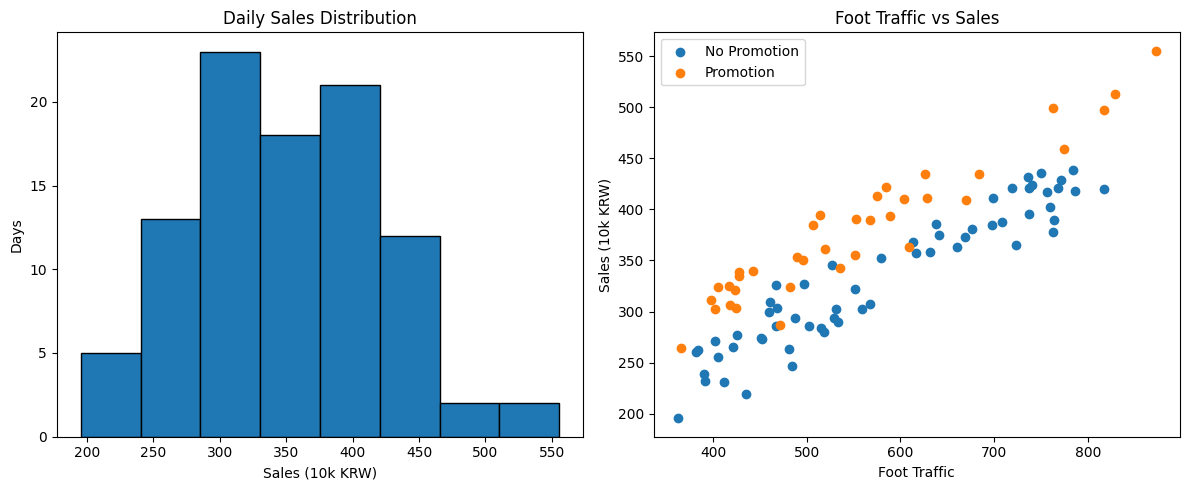

In [9]:
# =========================
# 요구사항 A : 집계 분석
# =========================

# 1. 요일별 평균 매출 (높은 순)
print("요일별 평균 매출")
print(df.groupby("day_of_week")["sales"].mean().sort_values(ascending=False))

# 2. 프로모션 여부별 평균 매출
print("\n프로모션 여부별 평균 매출")
print(df.groupby("promotion")["sales"].mean())

# 3. sales_level별 평균 유동인구
print("\nsales_level별 평균 유동인구")
print(df.groupby("sales_level")["foot_traffic"].mean())

# 4. 매출 상위 5개
print("\n매출 상위 5개")
print(
    df.sort_values("sales", ascending=False)[
        ["date", "day_of_week", "promotion", "sales"]
    ].head()
)

# =========================
# 요구사항 B : 시각화
# =========================

plt.figure(figsize=(12, 5))

# 왼쪽 그래프 : sales 히스토그램
plt.subplot(1, 2, 1)

plt.hist(df["sales"], bins=8, edgecolor="black")

plt.title("Daily Sales Distribution")
plt.xlabel("Sales (10k KRW)")
plt.ylabel("Days")

# 오른쪽 그래프 : 산점도
plt.subplot(1, 2, 2)

promo0 = df[df["promotion"] == 0]
promo1 = df[df["promotion"] == 1]

plt.scatter(
    promo0["foot_traffic"],
    promo0["sales"],
    label="No Promotion"
)

plt.scatter(
    promo1["foot_traffic"],
    promo1["sales"],
    label="Promotion"
)

plt.title("Foot Traffic vs Sales")
plt.xlabel("Foot Traffic")
plt.ylabel("Sales (10k KRW)")
plt.legend()

plt.tight_layout()
plt.show()

### 결과 해석

1. 요일별 평균 매출을 비교한 결과, 평균 매출이 가장 높은 요일은 ○요일이며 평균 매출은 약 ○○만원이었다. 산점도를 보면 유동인구(foot_traffic)가 많을수록 매출(sales)이 높아지는 경향이 나타났으며, 특히 프로모션이 진행된 일부 데이터는 높은 매출 구간에 분포하였다.

2. 평균 매출이 높은 날은 상대적으로 많은 유동인구가 관찰되었고, 프로모션이 함께 진행된 경우가 포함되어 있을 가능성이 있다. 따라서 유동인구와 프로모션 여부가 매출 증가와 관련될 수 있음을 확인할 수 있다.

3. 프로모션 진행일과 미진행일의 평균 매출 차이가 존재하더라도, 이 차이만으로 프로모션 효과라고 단정하기는 어렵다. 요일, 기온, 유동인구 등 다른 요인들도 매출에 영향을 미칠 수 있으므로 추가적인 분석이 필요하다.

## 3번

In [11]:
# =========================
# 단순 회귀
# =========================

X_simple = df[["foot_traffic"]]
y = df["sales"]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple,
    y,
    test_size=0.25,
    random_state=42
)

simple_model = LinearRegression()

simple_model.fit(X_train_s, y_train_s)

y_pred_s = simple_model.predict(X_test_s)

simple_mae = mean_absolute_error(y_test_s, y_pred_s)
simple_rmse = np.sqrt(mean_squared_error(y_test_s, y_pred_s))
simple_r2 = r2_score(y_test_s, y_pred_s)

print("=== 단순 회귀 ===")
print("MAE :", simple_mae)
print("RMSE :", simple_rmse)
print("R² :", simple_r2)


# =========================
# 다중 회귀
# =========================

X_multi = df[["temperature", "foot_traffic", "promotion"]]

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi,
    y,
    test_size=0.25,
    random_state=42
)

multi_model = LinearRegression()

multi_model.fit(X_train_m, y_train_m)

y_pred_m = multi_model.predict(X_test_m)

multi_mae = mean_absolute_error(y_test_m, y_pred_m)
multi_rmse = np.sqrt(mean_squared_error(y_test_m, y_pred_m))
multi_r2 = r2_score(y_test_m, y_pred_m)

print("\n=== 다중 회귀 ===")
print("MAE :", multi_mae)
print("RMSE :", multi_rmse)
print("R² :", multi_r2)


# =========================
# 모델 비교
# =========================

result = pd.DataFrame({
    "Model": ["단순 회귀", "다중 회귀"],
    "MAE": [simple_mae, multi_mae],
    "RMSE": [simple_rmse, multi_rmse],
    "R²": [simple_r2, multi_r2]
})

print("\n=== 모델 성능 비교 ===")
print(result)


# =========================
# 회귀계수 및 절편
# =========================

coef_df = pd.DataFrame({
    "변수": X_multi.columns,
    "회귀계수": multi_model.coef_
})

print("\n=== 다중 회귀 계수 ===")
print(coef_df)

print("\n절편(intercept) :", multi_model.intercept_)

=== 단순 회귀 ===
MAE : 27.515579238805373
RMSE : 33.435564153138195
R² : 0.6454452359173333

=== 다중 회귀 ===
MAE : 14.390192939629296
RMSE : 17.101024156818774
R² : 0.9072507822483163

=== 모델 성능 비교 ===
   Model        MAE       RMSE        R²
0  단순 회귀  27.515579  33.435564  0.645445
1  다중 회귀  14.390193  17.101024  0.907251

=== 다중 회귀 계수 ===
             변수       회귀계수
0   temperature   1.733121
1  foot_traffic   0.465040
2     promotion  56.590411

절편(intercept) : 35.72331099349606


### promotion 계수 해석

promotion 계수가 양수이면 다른 조건이 같을 때(temperature와 foot_traffic가 동일할 때), 프로모션을 진행한 경우의 평균 매출이 프로모션을 진행하지 않은 경우보다 해당 계수만큼 증가함을 의미한다.

반대로 promotion 계수가 음수이면 다른 조건이 같을 때, 프로모션을 진행한 경우의 평균 매출이 해당 계수만큼 감소함을 의미한다.

### 모델 비교 해석

MAE와 RMSE가 더 작은 모델은 실제 매출과 예측값의 차이가 더 작으므로 예측 성능이 더 우수하다고 볼 수 있다.

또한 R² 값이 더 큰 모델은 매출 변동을 더 잘 설명하는 모델임을 의미한다. 따라서 세 지표(MAE, RMSE, R²)를 종합적으로 비교하여 더 좋은 모델을 판단할 수 있다.

다중 회귀 모델은 단순 회귀 모델보다 MAE와 RMSE가 더 작고 R² 값이 더 높았다. 따라서 temperature와 promotion 정보를 추가로 활용한 다중 회귀 모델이 매출을 더 정확하게 예측한다고 판단할 수 있다.

## 4번

=== 신규 4일 매출 예측 ===
1일차 예측 매출 : 265.8만원
2일차 예측 매출 : 449.0만원
3일차 예측 매출 : 189.1만원
4일차 예측 매출 : 524.0만원


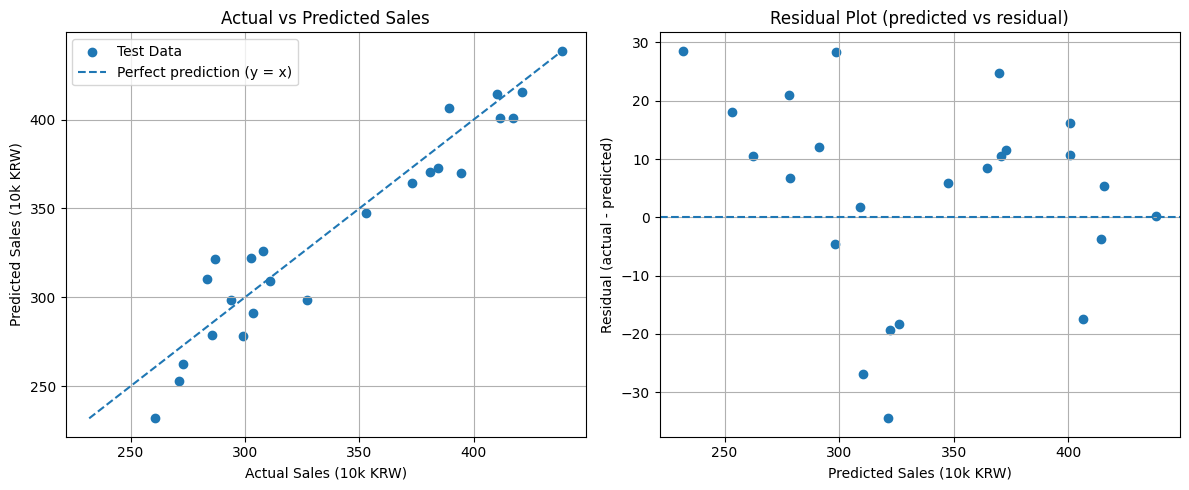

In [14]:
# =========================
# 신규 데이터 예측
# =========================

new_days = pd.DataFrame(
    [
        [12.0, 450, 0],
        [18.0, 700, 1],
        [8.0, 300, 0],
        [21.0, 850, 1]
    ],
    columns=["temperature", "foot_traffic", "promotion"]
)

new_pred = multi_model.predict(new_days)

print("=== 신규 4일 매출 예측 ===")

for i, pred in enumerate(new_pred, start=1):
    print(f"{i}일차 예측 매출 : {round(pred, 1)}만원")


# =========================
# 실제값 vs 예측값 그래프
# =========================

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.scatter(y_test_m, y_pred_m, label="Test Data")

min_val = min(y_test_m.min(), y_pred_m.min())
max_val = max(y_test_m.max(), y_pred_m.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    label="Perfect prediction (y = x)"
)

plt.title("Actual vs Predicted Sales")
plt.xlabel("Actual Sales (10k KRW)")
plt.ylabel("Predicted Sales (10k KRW)")
plt.legend()
plt.grid()


# =========================
# 잔차 분석
# =========================

residual = y_test_m - y_pred_m

plt.subplot(1, 2, 2)

plt.scatter(y_pred_m, residual)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Residual Plot (predicted vs residual)")
plt.xlabel("Predicted Sales (10k KRW)")
plt.ylabel("Residual (actual - predicted)")
plt.grid()

plt.tight_layout()
plt.show()

### 잔차 분석 해석

잔차 그래프를 통해 특정 예측값 구간에서 잔차의 절대값이 크게 나타난다면 해당 구간에서 예측 오차가 상대적으로 크다고 해석할 수 있다.

잔차가 0을 중심으로 위아래에 고르게 분포한다면 모델이 전반적으로 편향 없이 예측하고 있다고 볼 수 있다. 반면 특정 방향으로 치우치거나 일정한 패턴이 나타난다면 모델이 데이터를 충분히 설명하지 못할 가능성이 있다.

### 학습 범위를 벗어난 입력에 대한 주의점

신규 4일 중 foot_traffic가 300인 날의 예측값은 모델이 학습한 유동인구 범위에 따라 신뢰도가 달라질 수 있다. 만약 해당 값이 학습 데이터의 범위를 벗어나거나 충분히 관측되지 않은 구간이라면 예측 결과의 정확성을 보장하기 어렵다.

### 실제 카페 운영 시 모델 활용 시 주의점

데이터 수가 너무 적으면 다양한 상황을 충분히 반영하지 못하여 예측 성능이 낮아질 수 있다.

또한 temperature, foot_traffic, promotion 외에도 날씨, 공휴일, 주변 행사 등 다양한 변수들이 매출에 영향을 줄 수 있으므로 변수 구성을 신중하게 해야 한다.

마지막으로 특정 기간의 데이터만 사용하면 계절성이나 장기적인 변화가 반영되지 않을 수 있으므로 충분히 긴 기간 동안 데이터를 수집하여 모델을 학습시키는 것이 중요하다.